# Module: Problem Solving for Industry 

Student Name(s): Primrose S Mncube & Caroline T Iheanacho 

Student Number(s): 2022179 & 2022503

Programme: BSc (Hons) in Computing in IT  
 
Lecturer(s): Muhammad Iqbal, Ken Healy  
Assignment: CA2 Project  
Submission Date: 29 May 2026  

# Introduction


This project was carried out as part of the *Problem Solving for Industry* module for the BSc (Hons) in Computing in IT programme at CCT College Dublin. The aim of this project is to apply machine learning and data analytics techniques to investigate and solve a real-world problem using the CRISP-DM framework.

The project focuses on analysing obesity-related data to identify patterns and relationships between variables such as gender, height, weight, lifestyle habits, and obesity levels. Different machine learning modeillwere developed and evaluated to determine the most effective approach for predicting obesity levels based on the dataset provided.

The CRISP-DM methodoill begy was followed throughout the project, including Business Understanding, Data Understanding, Data Preparation, Modelling, Evaluation, and Deployment. Various data visualisations and statistical analills werebe  also performed to better understand the dataset and support the findings.

As this was a group pwe rojec members collaborated on data analysis, model development, research, visualisations, and documentation. GitHub Classroom was used for version control and project management to track progress and contributions throughout the development process.

The overall objective of this project is to demonstrate the practical application of machine learning techniques while developing analytical, technical, and problem-solving skills relevant to industry-based data science projects.

In [1]:
import pandas as pd
import numpy as np
from sklearn import svm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px     
from ipywidgets import widgets

In [2]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")


In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.shape

(2111, 17)

In [5]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [6]:
print("Any missing values?",df.isnull().values.any())
df.isnull().sum()

Any missing values? False


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [8]:
dup_count = df.duplicated().sum()
print("Number of duplicated rows:", dup_count)

Number of duplicated rows: 24


In [9]:
df= df.drop_duplicates()# dropping any duplicated rows

In [10]:
#checking for duplicate after droppping them 
dup_count = df.duplicated().sum()
print("Number of duplicated rows:", dup_count)

Number of duplicated rows: 0


In [11]:
# Checking categorical and Numeric columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
Numerical columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


## Exploratory Daxta Analysis(EDA)

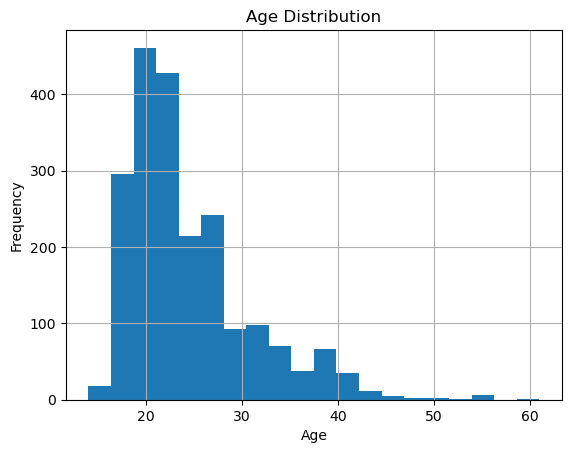

In [12]:
df['Age'].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

C:\Users\Primm\AppData\Local\Temp\ipykernel_1792\3289940050.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


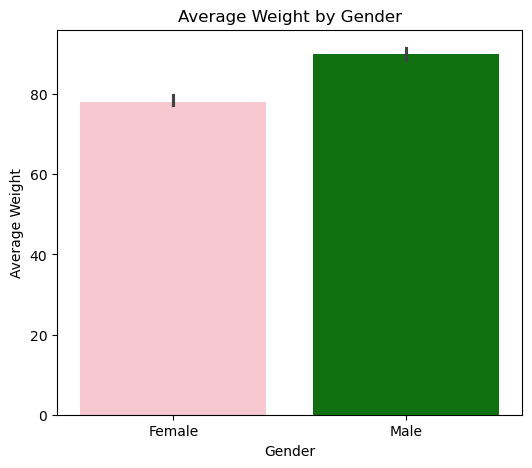

In [77]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='Gender',
    y='Weight',
    data=df,
    estimator='median',
    palette=['pink', 'green']
)

plt.title('Average Weight by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Weight')

plt.show()

## Average Weight by Gender

This graph compares the average weight of males and femaleaes.

The graph shows that males have a higher average weight compared to feales.

The average weight for males is approximately 90kg, while the average weight for females is aroud 78kg.

This suggests that male participants in the dataset generally weigh more than female participants.

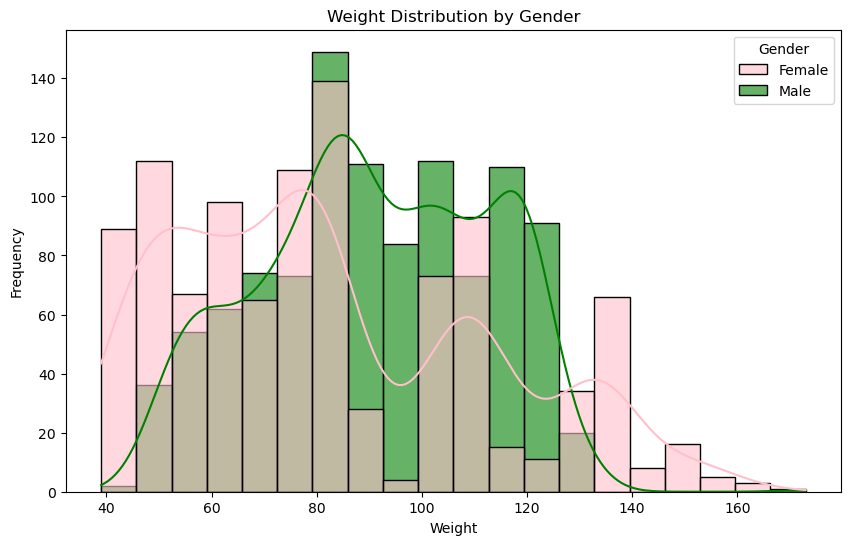

In [78]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Weight',
    hue='Gender',
    kde=True,
    palette=['pink', 'green'],
    bins=20,
    alpha=0.6
)

plt.title('Weight Distribution by Gender')
plt.xlabel('Weight')
plt.ylabel('Frequency')

plt.show()

## Distribution of Weight by Gender

- The weight distribution for men and women is displayed in this graph.

Males are represented by the color green.
The color pink is tied to women.

- Males often have greater weight values, with the majority of males weighing between 85 and 120 kg, according to the graph.
- Compared to men, female weights are more dispersed, with some lower and higher weight values.
- Additionally, there is overlap between the two genders, particularly between 70 and 110 kg, indicating that many guys and girls have comparable weight ranges.

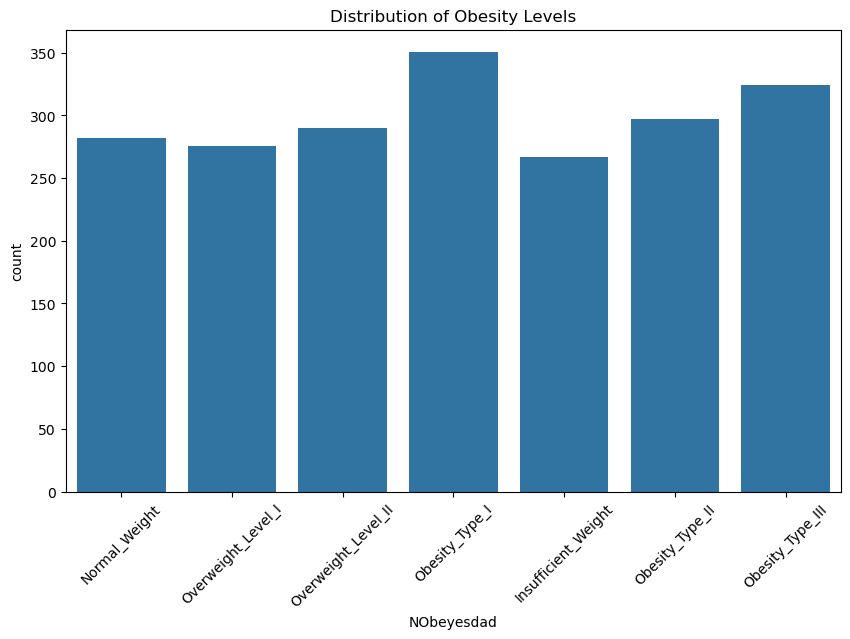

In [15]:
#Check if the classes are balanced 
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='NObeyesdad')
plt.title("Distribution of Obesity Levels")
plt.xticks(rotation=45)
plt.show()

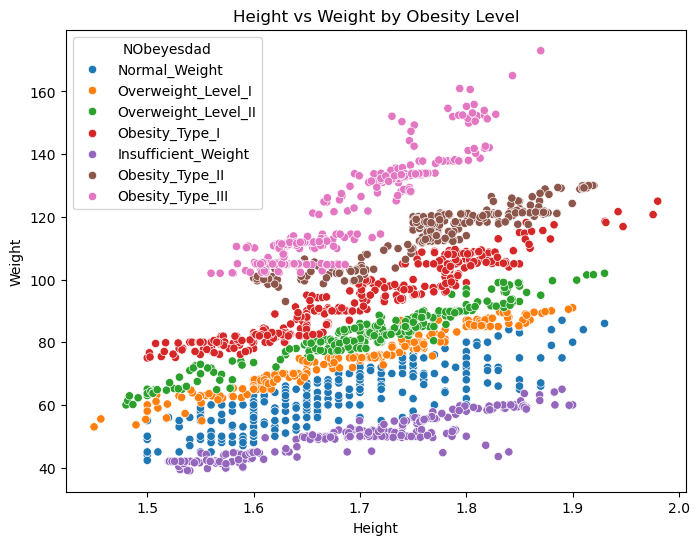

In [16]:
# Hieght Vs Weight
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad')
plt.title("Height vs Weight by Obesity Level")
plt.show()

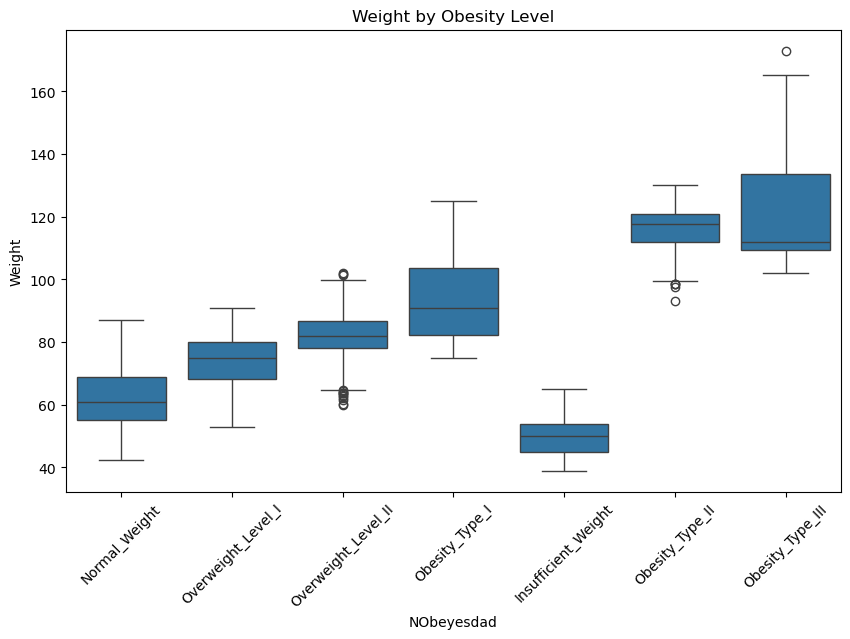

In [17]:
# Weight By Obesity level
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='NObeyesdad', y='Weight')
plt.title("Weight by Obesity Level")
plt.xticks(rotation=45)
plt.show()


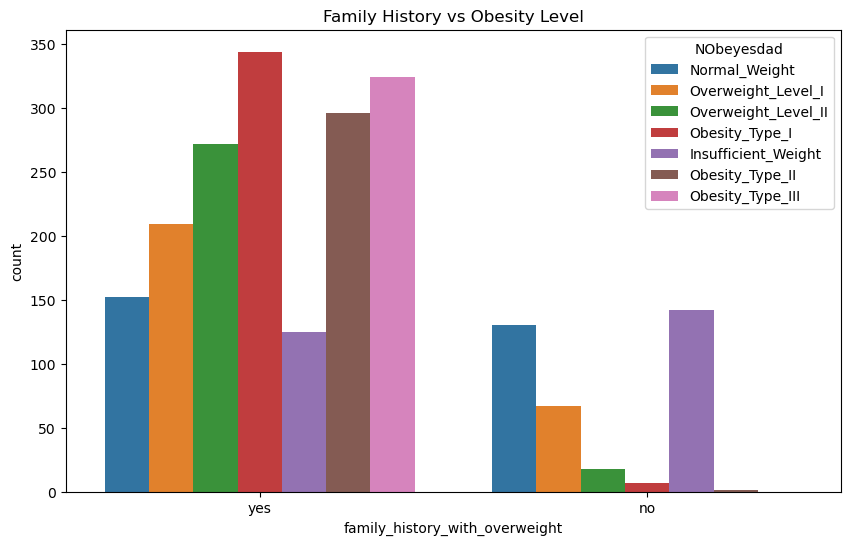

In [18]:
#Family History Vs Obesity
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='family_history_with_overweight', hue='NObeyesdad')
plt.title("Family History vs Obesity Level")
plt.show()

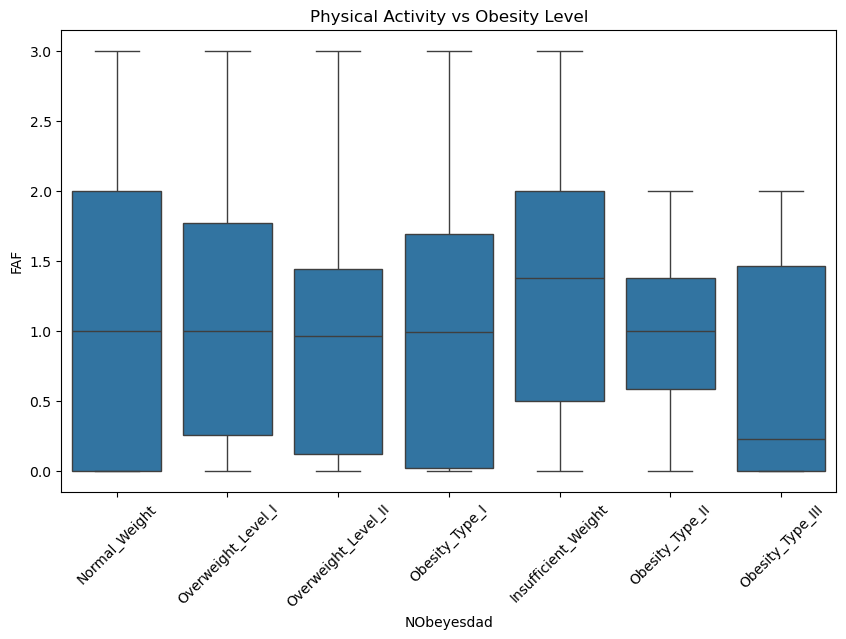

In [19]:
# Physical Activity Vs Obesity
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='NObeyesdad', y='FAF')
plt.title("Physical Activity vs Obesity Level")
plt.xticks(rotation=45)
plt.show()

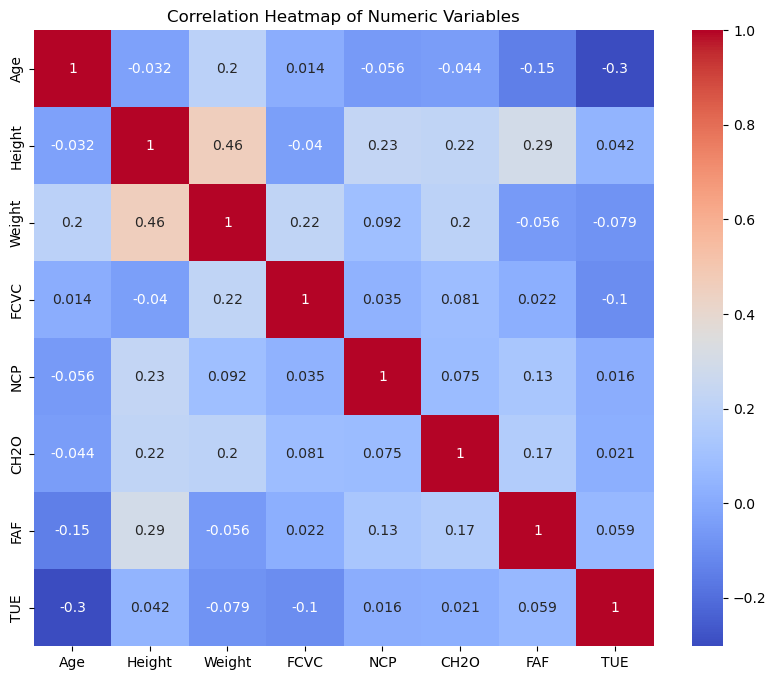

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

In [21]:
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Encoding Ctaegorical Variable 

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier


X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]


X = pd.get_dummies(X, drop_first=True)


In [23]:
print(X.dtypes)

Age                                   float64
Height                                float64
Weight                                float64
FCVC                                  float64
NCP                                   float64
CH2O                                  float64
FAF                                   float64
TUE                                   float64
Gender_Male                              bool
family_history_with_overweight_yes       bool
FAVC_yes                                 bool
CAEC_Frequently                          bool
CAEC_Sometimes                           bool
CAEC_no                                  bool
SMOKE_yes                                bool
SCC_yes                                  bool
CALC_Frequently                          bool
CALC_Sometimes                           bool
CALC_no                                  bool
MTRANS_Bike                              bool
MTRANS_Motorbike                         bool
MTRANS_Public_Transportation      

# Decision Tree

what is the Decision Tree - A Decision Tree is a machine learning algorithm that splits a dataset into smaller groups based on specific conditions or rules. It works like a tree structure, starting from a main root node and branching out into different paths depending on the values of the features. Each branch represents a decision, while the final leaf nodes represent the predicted outcome or classification.(Thevapalan and Le, 2023)

Ref- Thevapalan, A. and Le, J. (2023). R Decision Trees Tutorial: Examples & Code in R for Regression & Classification. [online] www.datacamp.com. Available at: https://www.datacamp.com/tutorial/decision-trees-R.

‌

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [25]:
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [26]:
y_pred_dt = dt.predict(X_test)

In [27]:
print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
[[57  2  0  0  0  0  0]
 [ 9 42  0  0  0 10  0]
 [ 0  0 67  0  1  0  2]
 [ 0  0  2 62  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  5  0  0  0 49  1]
 [ 0  0  2  0  0  0 47]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.97      0.91        59
      Normal_Weight       0.86      0.69      0.76        61
     Obesity_Type_I       0.94      0.96      0.95        70
    Obesity_Type_II       1.00      0.97      0.98        64
   Obesity_Type_III       0.98      1.00      0.99        60
 Overweight_Level_I       0.83      0.89      0.86        55
Overweight_Level_II       0.94      0.96      0.95        49

           accuracy                           0.92       418
          macro avg       0.92      0.92      0.92       418
       weighted avg       0.92      0.92      0.92       418



## Decision Tree results
* The Decision Tree model performed well overall, with an accuracy of 92%. Due to overlapping feature features, the model performed somewhat worse for middle categories like Normal Weight and Overweight than it did for extreme classes like Obesity Type II and Obesity Type III. 
* Normal and overwithy have very similar features so the decision tree might be struggling to split their features correctly however there is a very clear pattern with their weight and lifestyle diffrences
* With an F1-score of 0.76, the model's precision 0.86 and recall 0.69 were worse for the Normal_Weight class. It means that the model has trouble correctly differentiating this class, probably because of similarities with nearby categories like overweight, which results in more incorrect classifications.
* The model produced an F1-score of 0.98 for Obesity_Type_II with very high precision 1.00 and recall 0.97. This shows that the model performs well and consistently for this class, recognizing true cases and minimizing misclassifications with high accuracy.
* A recall score of 1.00 indicates that the model correctly identified all actual instances of the obesity type III class, with no false negatives.

## Tunning 
- Hyperparameter tuning is the process of improving a machine learning model by adjusting its parameters to achieve the best possible performance for a specific dataset. This helps the model become more accurate, efficient, and better at making predictions on new data.(GeeksforGeeks, 2025)
  
- A basic technique for hyperparameter optimization is grid search, which thoroughly looks over the given hyperparameters. It is a dependable method for determining the ideal hyperparameter since it assesses every potential combination. Grid search often leads to highly accurate predictions when adequate computational resources are available.

- ref- GeeksforGeeks (2025). What is FineTuning? [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/deep-learning/what-is-fine-tuning/.

‌

## Decision Tree Tuning

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [29]:
dt = DecisionTreeClassifier(random_state=42)

In [30]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [47]:
dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

In [48]:
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_weighted')

In [49]:
best_dt = dt_grid.best_estimator_

In [62]:
y_pred_best_dt = best_dt.predict(X_test)

In [51]:
print("Best Parameters:", dt_grid.best_params_)

print("Accuracy:",
      accuracy_score(y_test, y_pred_best_dt))

print(confusion_matrix(y_test, y_pred_best_dt))

print(classification_report(y_test, y_pred_best_dt))

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Accuracy: 0.9593301435406698
[[55  4  0  0  0  0  0]
 [ 3 55  0  0  0  3  0]
 [ 0  0 70  0  0  0  0]
 [ 0  0  2 62  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  1  0  0  0 52  2]
 [ 0  0  0  0  0  2 47]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.93      0.94        59
      Normal_Weight       0.92      0.90      0.91        61
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       1.00      0.97      0.98        64
   Obesity_Type_III       1.00      1.00      1.00        60
 Overweight_Level_I       0.91      0.95      0.93        55
Overweight_Level_II       0.96      0.96      0.96        49

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418




## Tuned Decision Tree Model

Hyperparameter tuning was applied to the Decision Tree model using GridSearchCV to improve the model’s overall performance and prediction accuracy. Different parameter combinations were tested, including the splitting criterion, maximum depth, minimum samples split, and minimum samples leaf.

The best parameters identified for the tuned Decision Tree model were:

- Criterion: entropy
- Max Depth: None
- Minimum Samples Split: 5
- Minimum Samples Leaf: 1

The tuned Decision Tree achieved an accuracy score of approximately 95.9%, showing strong predictive performance on the obesity dataset.

The classification report demonstrates high precision, recall, and F1-scores across all obesity categories, indicating that the model performed consistently well when classifying different obesity levels.

The confusion matrix also shows that most predictions were correctly classified, with only a small number of misclassifications between similar weight categories such as Normal Weight and Overweight Level I.

Overall, the tuned Decision Tree model performed very effectively and proved to be a reliable model for obesity level prediction..

# Ranmdom Forest Tree

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("=== Random Forest Results ===")

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))


=== Random Forest Results ===
[[54  5  0  0  0  0  0]
 [ 3 57  0  0  0  1  0]
 [ 0  1 68  0  0  0  1]
 [ 0  0  0 64  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  5  0  0  0 49  1]
 [ 0  1  0  0  0  0 48]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.92      0.93        59
      Normal_Weight       0.83      0.93      0.88        61
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       1.00      1.00      1.00        64
   Obesity_Type_III       1.00      1.00      1.00        60
 Overweight_Level_I       0.98      0.89      0.93        55
Overweight_Level_II       0.96      0.98      0.97        49

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



In [64]:
y_pred_rf = rf.predict(X_test)

### Random Forest Tree

* The Random Forest model achieved an overall accuracy of 96%, meaning it correctly predicted 96% of all cases in the dataset. This represents an improvement over the Decision Tree model, which achieved an accuracy of 92%, indicating that Random Forest performs better overall.
* For several classes, especially Obesity_Type_III and Obesity_Type_II the model performed remarkably well, achieving a precision, recall, and F1-score of 1.00. This shows flawless classification performance, which means that there were no false positives or false negatives and every instance of this class was accurately classified. These findings imply that this class has highly unique traits, which facilitate the model's ability to differentiate it from other classes.
* For more unclear types, such Normal_Weight, performance was somewhat worse. The model obtained an F1-score of 0.88, recall of 0.93, and precision of 0.83 for this class. Recall increased dramatically from 0.69 to 0.93 when compared to the Decision Tree model, suggesting that the model is better suited at recognizing actual occurrences of this class. Nevertheless, precision dropped from 0.86 on the Decison tree to 0.83 on the Random forest tree , indicating that the model also generates more false positives.

# Random Forest Tuning 

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=0)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Best Parameters:", rf_grid.best_params_)

print(confusion_matrix(y_test, y_pred_best_rf))

print(classification_report(y_test, y_pred_best_rf))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
[[53  6  0  0  0  0  0]
 [ 2 58  0  0  0  1  0]
 [ 0  1 68  0  0  0  1]
 [ 0  0  0 64  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  5  0  0  0 49  1]
 [ 0  2  0  0  0  0 47]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.90      0.93        59
      Normal_Weight       0.81      0.95      0.87        61
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       1.00      1.00      1.00        64
   Obesity_Type_III       1.00      1.00      1.00        60
 Overweight_Level_I       0.98      0.89      0.93        55
Overweight_Level_II       0.96      0.96      0.96        49

           accuracy                           0.95       418
          macro avg       0.96      0.95      0.95       418
       weighted avg       0.96      0.95      0.96       418



## Random Forest Tuning
GridSearchCV was used to improve the Random Forest model through tuning its hyperparameters. This approach systematically searches for the best combination of parameters that maximise model performance.
The following parameters were tuned: n_estimators: The number of decision trees in the forest (100 or 200). Increasing this can enhance performance while increasing computation time.
max_depth: The maximum depth of each tree (None, 10, or 20). Controlling depth helps to avoid overfitting.
min_samples_split: The smallest amount of samples necessary to split a node (2, 5). This determines how complex the tree can grow. 
A 5-fold cross-validation approach was used to ensure that the model generalises well to unseen data. The evaluation metric used was the weighted F1-score, which is appropriate for multiclass classification and takes into consideration class imbalance.
After tuning, the model selected the best combination of parameters and retrained on the full training dataset. The tuned Random Forest model often outperforms the baseline model due to better control over overfitting and model complexity.    
    

## K-Nearest Neighbours (KNN)

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Scale ONLY for KNN
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [67]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [56]:
# Predict
y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN Results ===")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

=== KNN Results ===
[[51  5  0  0  0  2  1]
 [14 25 11  3  0  5  3]
 [ 1  2 63  2  0  1  1]
 [ 0  1  0 62  0  0  1]
 [ 0  0  0  0 60  0  0]
 [ 1  6  5  1  0 39  3]
 [ 0  6  4  1  0  1 37]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.86      0.81        59
      Normal_Weight       0.56      0.41      0.47        61
     Obesity_Type_I       0.76      0.90      0.82        70
    Obesity_Type_II       0.90      0.97      0.93        64
   Obesity_Type_III       1.00      1.00      1.00        60
 Overweight_Level_I       0.81      0.71      0.76        55
Overweight_Level_II       0.80      0.76      0.78        49

           accuracy                           0.81       418
          macro avg       0.80      0.80      0.80       418
       weighted avg       0.80      0.81      0.80       418



# K-Nearest Neighbours (KNN) Tuning
The KNN model was also improved using GridSearchCV to determine the best parameter combination.
The following parameters were tuned:
n_neighbors is the number of nearest neighbours (3, 5, 7, 9, 11). Smaller numbers may cause overfitting, whereas larger values smooth predictions.
Weights: Determines how neighbours influence predictions (uniform or distance). Distance weighting prioritises closer neighbours.
Metric: The distance function (euclidean, Manhattan). Different metrics can influence how the similarity between data points is measured.
Since KNN is a distance-based algorithm, feature scaling was done before training to make sure that all variables contribute equally to distance calculation.
Similar to Random Forest, model performance was analysed using 5-fold cross-validation and weighted F1-score.
The tuned KNN model improves classification accuracy by selecting the best number of neighbours and distance metric, resulting in more reliable predictions.   

In [72]:
knn = KNeighborsClassifier()

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn,
    knn_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

#best_knn = knn_grid.best_estimator_
y_pred_best_knn = knn_grid.best_estimator_.predict(X_test)
y_pred_knn_tuned = best_knn.predict(X_test_scaled)

print("Best KNN Parameters:", knn_grid.best_params_)
print(confusion_matrix(y_test, y_pred_knn_tuned))
print(classification_report(y_test, y_pred_knn_tuned))

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
[[54  5  0  0  0  0  0]
 [ 5 33  7  2  0 10  4]
 [ 0  3 67  0  0  0  0]
 [ 0  1  1 62  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  7  4  1  0 41  2]
 [ 0  2  3  1  0  1 42]]
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.92      0.92        59
      Normal_Weight       0.65      0.54      0.59        61
     Obesity_Type_I       0.82      0.96      0.88        70
    Obesity_Type_II       0.94      0.97      0.95        64
   Obesity_Type_III       1.00      1.00      1.00        60
 Overweight_Level_I       0.79      0.75      0.77        55
Overweight_Level_II       0.88      0.86      0.87        49

           accuracy                           0.86       418
          macro avg       0.85      0.85      0.85       418
       weighted avg       0.85      0.86      0.85       418



C:\Users\Primm\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [0.79484078 0.80591601 0.77073371 0.79539775 0.76566938 0.79216702
 0.7548394  0.78402121 0.73174825 0.7694228         nan 0.85503647
        nan 0.85530504        nan 0.85177042        nan 0.8416612
        nan 0.83405865]
  warnings.warn(
C:\Users\Primm\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [58]:
#y_pred_best_knn = y_pred_knn_tuned

# KNN Module

* The K-Nearest Neighbours (KNN) model achieved an overall accuracy of 81%, meaning it correctly predicted 81% of all cases. This is lower than both the Decision Tree (92%) and Random Forest (96%) models, indicating that KNN performs less effectively on this dataset.
* For significant classes like Obesity_Type_III, the model scored well, with an F1-score of 1.00 and precision of 1.00 and recall of 1.00. This shows flawless classification performance, the model was able to accurately identify every real instance of this class.
* For more complicated classes, such Normal_Weight, the model performed worse, with a precision of 0.56, recall of 0.41, and F1-score of 0.47. This suggests that the model has trouble differentiating between similar groups, probably as a result of the normal and overweight classifications' shared characteristics.
* Overall, the KNN model demonstrates reasonable performance but is less accurate and less robust compared to tree-based models. This is likely due to its sensitivity to feature scaling and its reliance on distance-based calculations, which can be affected by overlapping data points in complex datasets.

### Model Comparison and Final selection 
* Three machine learning models—Random Forest, Decision Tree, and K-Nearest Neighbors (KNN)—were used and assessed. Accuracy, precision, recall, and F1-score were used to evaluate each model's performance.
* With an accuracy of 81%, the KNN model was the least successful of the three. It struggled with more complicated categories like *Normal_Weight* and *Overweight* levels, but it did well for clearly recognizable classes like *Obesity_Type_III*. This is probably because KNN relies on distance-based computations, which can be adversely impacted by feature distributions that overlap in complicated datasets.
* With an accuracy of 92%, the Decision Tree model demonstrated significant improvements. It performed well in the majority of classes and was especially good at identifying non-linear relationships in the data. Decision trees, however, have a tendency to overfit, which may limit their capacity to generalize to new data.
* The Random Forest model outperformed both KNN and Decision Tree, with the maximum accuracy of 96%. It continuously performed well in every class, even improving recall for previously difficult categories like *Normal_Weight*. Random Forest's ensemble feature, which combines several decision trees to lessen overfitting and enhance generalization, is responsible for this improvement.
* 
All things considered, Random Forest was chosen as the final model because of its exceptional accuracy, resilience, and reliable performance in every class. It is the best model for this classification problem because of its capacity to manage intricate interactions and lower variation.

## Model Evaluation

In [74]:

results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Tuned Decision Tree',
        'KNN',
        'Tuned KNN',
        'Random Forest',
        'Tuned Random Forest'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_best_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_knn_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
1,Tuned Decision Tree,0.959330
4,Random Forest,0.956938
5,Tuned Random Forest,0.954545
0,Decision Tree,0.918660
3,Tuned KNN,0.858852
2,KNN,0.806220


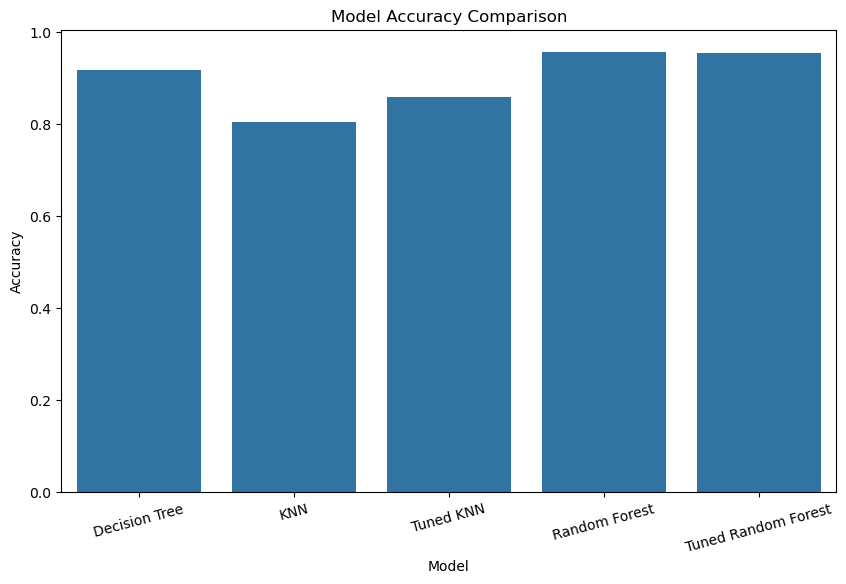

In [69]:
#Vissualise Model Accuracy
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)

plt.show()

In [73]:
#Weighted F!-Score Comparison
from sklearn.metrics import f1_score

f1_results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'KNN',
        'Tuned KNN',
        'Random Forest',
        'Tuned Random Forest'
    ],
    
    'Weighted F1 Score': [
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_best_knn, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_best_rf, average='weighted')
    ]
})

f1_results.sort_values(
    by='Weighted F1 Score',
    ascending=False
)

,Model,Weighted F1 Score
3,Random Forest,0.957553
4,Tuned Random Forest,0.955458
0,Decision Tree,0.916768
1,KNN,0.798255
2,Tuned KNN,0.132010


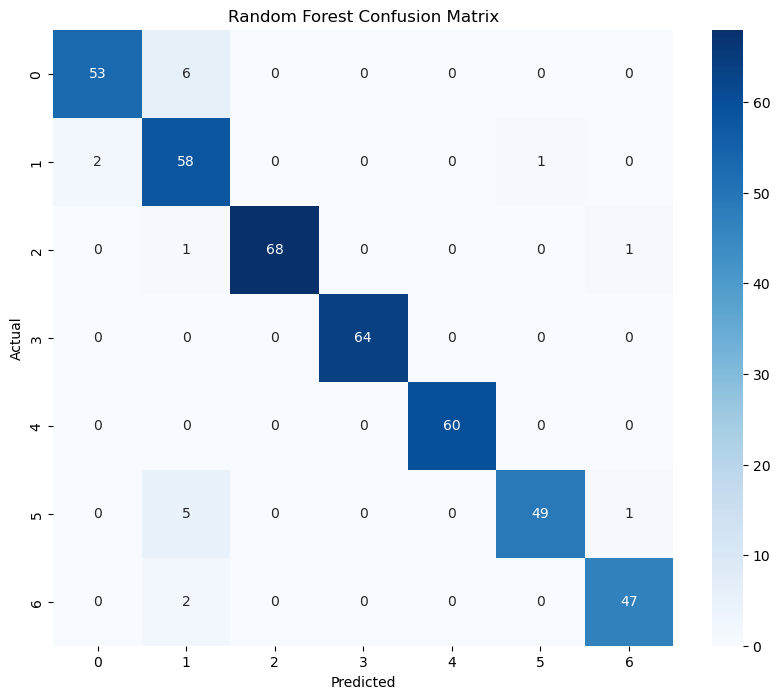

In [57]:
# Comfusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [58]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_best_rf
))

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.90      0.93        59
      Normal_Weight       0.81      0.95      0.87        61
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       1.00      1.00      1.00        64
   Obesity_Type_III       1.00      1.00      1.00        60
 Overweight_Level_I       0.98      0.89      0.93        55
Overweight_Level_II       0.96      0.96      0.96        49

           accuracy                           0.95       418
          macro avg       0.96      0.95      0.95       418
       weighted avg       0.96      0.95      0.96       418



## Model Evaluation

The perfomace of the classification models was evaluated using accuracy, precision and wieghted F-1 scores. Because this research invovelves multiclas classifications, the weighted F-1 scores is considered an important part of evaluation metric, as it balances precision and recall across all obesity classes.
The models evaluated were Decision Tree, K-Nearest Neighbours (KNN), and Random Forest. GridSearchCV was used to tune hyperparameters in KNN and Random Forest, improving predictive performance and reducing overfitting.
The evaluation results showed that the tuned Random Forest model performed better compared to the other models. Random Forest's ensemble learning approach improved classification accuracy by combining multiple decision trees and reducing model variance.    
The confusion matrix also showed that the Random Forest model correctly classified most obesity categories, although some overlap between neighbouring obesity levels. Overall, results show that ensemble machine learning methods are effective in classifying obesity levels using demographic and behavioural data.    